In [1]:
import numpy as np

x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)

In [ ]:
from scipy.stats import multivariate_normal

mu = np.array([0, 0])
Sigma = np.eye(2)

pos = np.stack([X1, X2], axis=-1)
Z = multivariate_normal(mean=mu, cov=Sigma).pdf(pos)

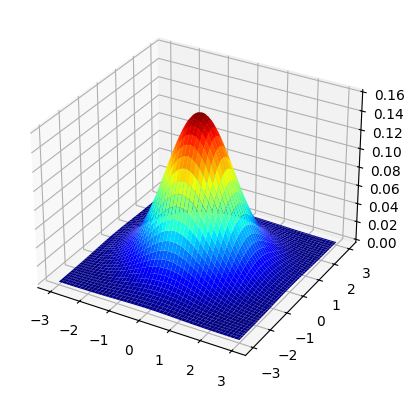

In [4]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, Z, cmap='jet')
plt.show()

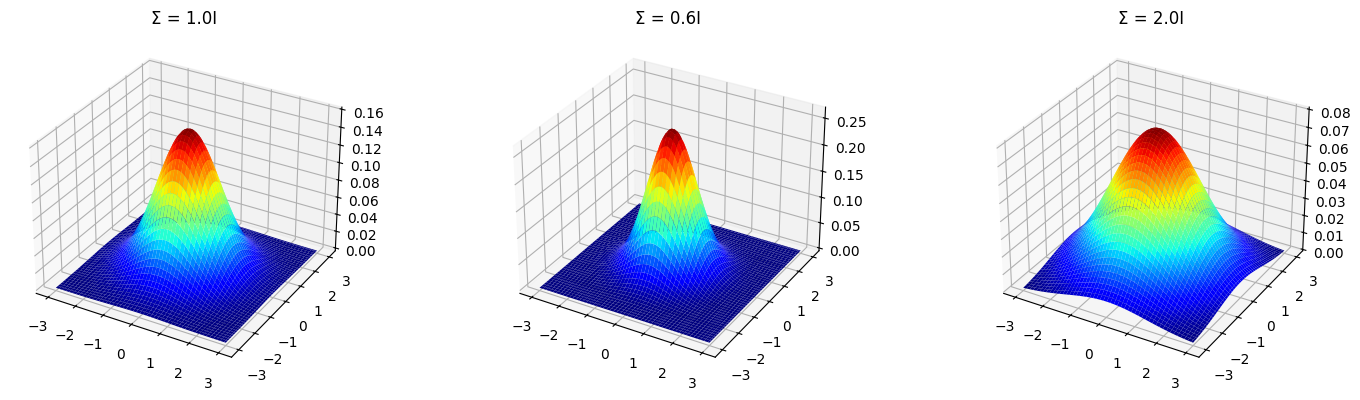

In [5]:
sigmas = [1.0, 0.6, 2.0]

fig, axes = plt.subplots(1, 3, subplot_kw={'projection': '3d'}, figsize=(15, 4))

for ax, s in zip(axes, sigmas):
    Sigma = s * np.eye(2)
    Z = multivariate_normal(mean=[0,0], cov=Sigma).pdf(pos)
    ax.plot_surface(X1, X2, Z, cmap='jet')
    ax.set_title(f'Σ = {s}I')

plt.tight_layout()
plt.show()

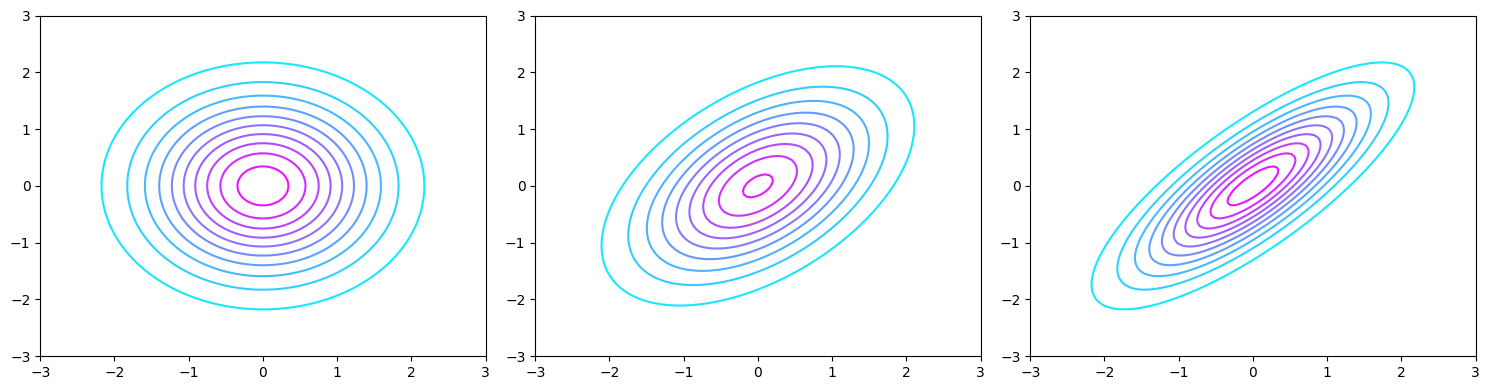

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    np.array([[1, 0], [0, 1]]),
    np.array([[1, 0.5], [0.5, 1]]),
    np.array([[1, 0.8], [0.8, 1]])
]

for ax, Sigma in zip(axes, configs):
    Z = multivariate_normal(mean=[0,0], cov=Sigma).pdf(pos)
    ax.contour(X1, X2, Z, levels=10, cmap='cool')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

plt.tight_layout()
plt.show()

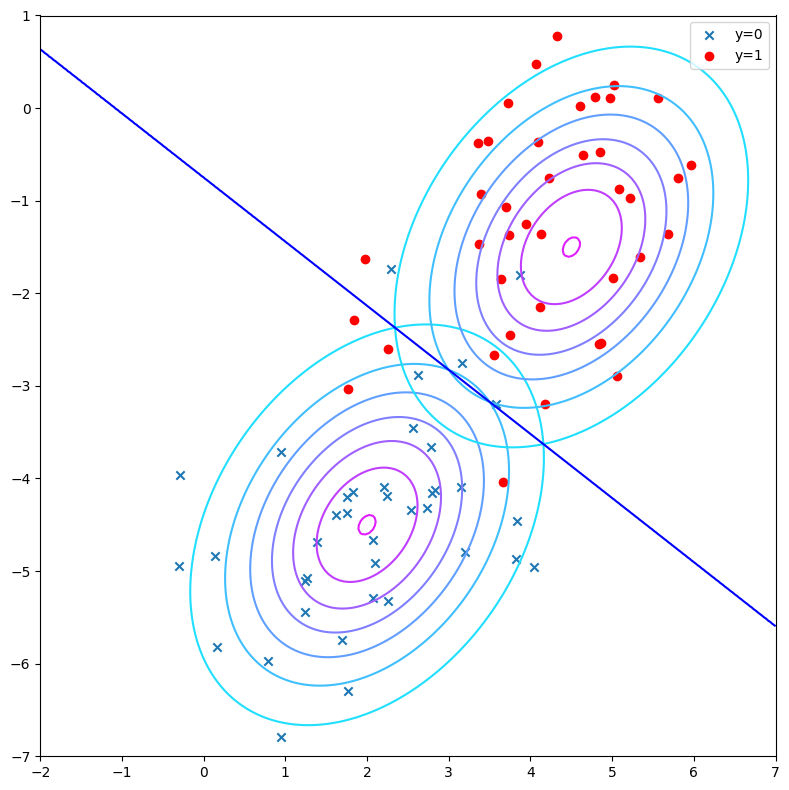

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# --- Data ---
np.random.seed(0)
mu0 = np.array([2, -4.5])
mu1 = np.array([4.5, -1.5])
Sigma = np.array([[1.2, 0.4], [0.4, 1.2]])

X0 = np.random.multivariate_normal(mu0, Sigma, 40)  # class 0: dấu x
X1 = np.random.multivariate_normal(mu1, Sigma, 40)  # class 1: vòng o

# --- Contour grid ---
x1 = np.linspace(-2, 7, 200)
x2 = np.linspace(-7, 1, 200)
X1g, X2g = np.meshgrid(x1, x2)
pos = np.stack([X1g, X2g], axis=-1)

Z0 = multivariate_normal(mean=mu0, cov=Sigma).pdf(pos)
Z1 = multivariate_normal(mean=mu1, cov=Sigma).pdf(pos)

# --- Decision boundary ---
# p(x|y=1)p(y=1) = p(x|y=0)p(y=0) => log-ratio = 0
# Với phi=0.5: boundary là Z1 - Z0 = 0
diff = Z1 - Z0

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X0[:, 0], X0[:, 1], marker='x', label='y=0')
ax.scatter(X1[:, 0], X1[:, 1], marker='o', facecolors='red', label='y=1')

ax.contour(X1g, X2g, Z0, levels=8, cmap='cool')
ax.contour(X1g, X2g, Z1, levels=8, cmap='cool')

ax.contour(X1g, X2g, diff, levels=[0], colors='blue', linewidths=1.5)

ax.set_xlim(-2, 7)
ax.set_ylim(-7, 1)
ax.legend()
plt.tight_layout()
plt.show()